# WGC Flight Data Audit


## 1. Project Objective

This notebook audits the sponsor-provided World Gliding Championship IGC flight-log archive to determine which aircraft metadata, altitude fields, engine-related measurements, and flight-behavior variables are available for analyzing mid-flight engine-start events.

The audit supports two primary sponsor questions:

1. Did a suspected mid-flight engine-start attempt occur above or below the applicable altitude-above-ground threshold?
2. Can recorded motor indicators and subsequent aircraft behavior help distinguish a successful engine start from a failed attempt, false-positive detection, or indeterminate event?

This notebook focuses on data inventory, parsing reproducibility, and quality assessment. It does not yet identify event times, assign engine-start outcomes, or evaluate pilot compliance.

## 2. Imports and Paths 

In [18]:

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR = Path("../data/wgc/wgc")
OUTPUT_DATA_DIR = Path("../data/processed")
OUTPUT_FIGURE_DIR = Path("../reports/figures")

OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

igc_files = sorted(
    list(DATA_DIR.glob("*.igc"))
    + list(DATA_DIR.glob("*.IGC"))
)

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"IGC files discovered: {len(igc_files)}")

Data directory: /Users/brookelumpkin/Library/Mobile Documents/com~apple~CloudDocs/UVA26_Sailplane-Capstone/data/wgc/wgc
IGC files discovered: 992


## 3. Dataset Overview

The sponsor-provided archive was extracted locally and excluded from Git version control because of its size. This section confirms the number of IGC files available and checks whether each file can be opened successfully.

In [19]:
# File readability will be checked during the full parsing step.
readable_files = igc_files.copy()
unreadable_files = []

print(f"Files discovered: {len(igc_files)}")
print(f"Files available for parsing: {len(readable_files)}")

Files discovered: 992
Files available for parsing: 992


In [20]:
print("First five readable files:")

for file_path in readable_files[:5]:
    print(file_path.name)

First five readable files:
4536-9239003137.igc
4536-9239003138.igc
4536-9239003139.igc
4536-9239003142.igc
4536-9239003143.igc


## 4. IGC Parsing Functions 

In [21]:
def parse_i_record(line: str) -> list[str]:
    """
    Parse an IGC I-record and return the declared three-letter extension codes.

    Structure:
    I + two-digit extension count + repeated groups of:
    start position (2 digits), end position (2 digits), code (3 characters)
    """
    line = line.strip()

    if not line.startswith("I") or len(line) < 3:
        return []

    try:
        extension_count = int(line[1:3])
    except ValueError:
        return []

    extensions = []

    for index in range(extension_count):
        start = 3 + index * 7
        group = line[start:start + 7]

        if len(group) != 7:
            continue

        code = group[4:7]

        if len(code) == 3 and code.isalnum():
            extensions.append(code)

    return extensions

In [22]:
def value_after_colon(line: str) -> str | None:
    """Return the portion of a header line after the first colon."""
    if ":" not in line:
        return None

    value = line.split(":", 1)[1].strip()
    return value or None

In [23]:
def audit_igc_file(file_path: Path) -> dict:
    """Extract flight-level metadata and declared IGC extensions."""

    record = {
        "file": file_path.name,
        "date": None,
        "glider_type": None,
        "recorder_type": None,
        "gps_receiver": None,
        "pressure_sensor": None,
        "motor_sensor": None,
        "extensions": set(),
        "b_record_count": 0,
        "valid_b_record_count": 0,
        "invalid_b_record_count":0,
        "has_i_record": False,
        "parse_error": None,
    }

    try:
        with file_path.open(
            "r",
            encoding="latin-1",
            errors="replace",
        ) as file:

            for raw_line in file:
                line = raw_line.strip()

                if line.startswith("HFDTEDATE"):
                    record["date"] = value_after_colon(line)

                elif line.startswith("HFGTYGLIDERTYPE"):
                    record["glider_type"] = value_after_colon(line)

                elif line.startswith("HFFTYFRTYPE"):
                    record["recorder_type"] = value_after_colon(line)

                elif line.startswith("HFGPSRECEIVER"):
                    record["gps_receiver"] = value_after_colon(line)

                elif line.startswith("HFPRSPRESSALTSENSOR"):
                    record["pressure_sensor"] = value_after_colon(line)

                elif line.startswith("HFMOPSENSOR"):
                    record["motor_sensor"] = value_after_colon(line)

                elif line.startswith("I"):
                    record["has_i_record"] = True
                    record["extensions"].update(parse_i_record(line))

                elif line.startswith("B"):
                    record["b_record_count"] += 1
                    if len(line) > 24:
                        validity_flag = line[24]
                        if validity_flag == "A":
                            record["valid_b_record_count"] += 1
                        elif validity_flag == "V":
                            record["invalid_b_record_count"] += 1

    except OSError as error:
        record["parse_error"] = str(error)

    return record

## 5. Flight-Level Inventory 

In [24]:
audit_records = []

for index, file_path in enumerate(readable_files, start=1):
    audit_records.append(audit_igc_file(file_path))

    if index % 50 == 0:
        print(f"Processed {index} / {len(readable_files)} files")

flight_inventory = pd.DataFrame(audit_records)

print(f"\nInventory rows created: {len(flight_inventory)}")
flight_inventory.head()

Processed 50 / 992 files
Processed 100 / 992 files
Processed 150 / 992 files
Processed 200 / 992 files
Processed 250 / 992 files
Processed 300 / 992 files
Processed 350 / 992 files
Processed 400 / 992 files
Processed 450 / 992 files
Processed 500 / 992 files
Processed 550 / 992 files
Processed 600 / 992 files
Processed 650 / 992 files
Processed 700 / 992 files
Processed 750 / 992 files
Processed 800 / 992 files
Processed 850 / 992 files
Processed 900 / 992 files
Processed 950 / 992 files

Inventory rows created: 992


,file,date,glider_type,recorder_type,gps_receiver,pressure_sensor,motor_sensor,extensions,b_record_count,valid_b_record_count,invalid_b_record_count,has_i_record,parse_error
0,4536-9239003137.igc,"110824,1",JS-3-18m_2L,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m","LXV,ON,ACOUSTIC,MOP-(SN:10161,ET=582,41,582,41...","{ACZ, MOP, AOR, AOA, TRT, AOP, SIU, ENL, VAT, ...",13618,13616,2,True,None
1,4536-9239003138.igc,"110824,1",18m AS33 @ventus,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",None,"{ACZ, AOR, AOA, TRT, AOP, SIU, ENL, VAT, OAT, ...",12240,12222,18,True,None
2,4536-9239003139.igc,"110824,1",JS-3-18m,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",None,"{ACZ, AOR, AOA, TRT, AOP, SIU, ENL, VAT, OAT, ...",14131,14131,0,True,None
3,4536-9239003142.igc,None,JS-3-18m,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",None,"{TRT, VAT, ENL, OAT, ACZ, TAS, GSP, FXA}",16260,16260,0,True,None
4,4536-9239003143.igc,None,AS 33Es 18m,"LXNAV,LX9070","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",None,"{TRT, VAT, ENL, OAT, ACZ, TAS, GSP, FXA}",14112,14112,0,True,None


In [25]:
candidate_variables = [
    "FXA",
    "ENL",
    "MOP",
    "RPM",
    "TAS",
    "GSP",
    "VAT",
    "NET",
    "ACZ",
    "AOR",
    "AOP",
    "OAT",
]

for variable in candidate_variables:
    flight_inventory[variable] = flight_inventory["extensions"].apply(
        lambda extensions: variable in extensions
    )

flight_inventory["extension_count"] = (
    flight_inventory["extensions"].apply(len)
)

flight_inventory.head()

,file,date,glider_type,recorder_type,gps_receiver,pressure_sensor,motor_sensor,extensions,b_record_count,valid_b_record_count,...,RPM,TAS,GSP,VAT,NET,ACZ,AOR,AOP,OAT,extension_count
0,4536-9239003137.igc,"110824,1",JS-3-18m_2L,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m","LXV,ON,ACOUSTIC,MOP-(SN:10161,ET=582,41,582,41...","{ACZ, MOP, AOR, AOA, TRT, AOP, SIU, ENL, VAT, ...",13618,13616,...,False,True,True,True,True,True,True,True,True,14
1,4536-9239003138.igc,"110824,1",18m AS33 @ventus,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",None,"{ACZ, AOR, AOA, TRT, AOP, SIU, ENL, VAT, OAT, ...",12240,12222,...,False,True,True,True,True,True,True,True,True,13
2,4536-9239003139.igc,"110824,1",JS-3-18m,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",None,"{ACZ, AOR, AOA, TRT, AOP, SIU, ENL, VAT, OAT, ...",14131,14131,...,False,True,True,True,True,True,True,True,True,13
3,4536-9239003142.igc,None,JS-3-18m,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",None,"{TRT, VAT, ENL, OAT, ACZ, TAS, GSP, FXA}",16260,16260,...,False,True,True,True,False,True,False,False,True,8
4,4536-9239003143.igc,None,AS 33Es 18m,"LXNAV,LX9070","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",None,"{TRT, VAT, ENL, OAT, ACZ, TAS, GSP, FXA}",14112,14112,...,False,True,True,True,False,True,False,False,True,8


In [26]:
inventory_path = OUTPUT_DATA_DIR / "wgc_flight_inventory.csv"

inventory_to_save = flight_inventory.copy()

inventory_to_save["extensions"] = (
    inventory_to_save["extensions"]
    .apply(lambda values: ",".join(sorted(values)))
)

inventory_to_save.to_csv(
    inventory_path,
    index=False,
)

print(f"Saved flight inventory to: {inventory_path}")

Saved flight inventory to: ../data/processed/wgc_flight_inventory.csv


### Altitude Fields

Each standard IGC B record contains fixed-width fields for pressure altitude and GNSS altitude. These altitude fields are separate from the optional variables declared in the I record. Their presence, validity, and consistency will be evaluated during time-series extraction before calculating altitude above ground level.

## 6. Aircraft and Recording-Hardware Inventory

Aircraft and recorder diversity may affect which variables are available and whether a single detection method can be applied uniformly across the dataset.

In [27]:
aircraft_summary = (
    flight_inventory["glider_type"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("Glider_Type")
    .reset_index(name="File_Count")
)

aircraft_summary.head(15)

,Glider_Type,File_Count
0,JS-3-18m,248
1,Arcus M,135
2,JS-1-21m,123
3,EB 29R,63
4,Arcus T,49
5,Ventus 3T,41
6,AS 33Es 18m,27
7,ASG 32Mi,23
8,EB29R GBD,17
9,HpH Twinshark,17


In [28]:
recorder_summary = (
    flight_inventory["recorder_type"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("Recorder_Type")
    .reset_index(name="File_Count")
)

recorder_summary.head(15)

,Recorder_Type,File_Count
0,"LXNAV,LX9070PF",307
1,"LXNAV,LX9070",303
2,"LXNAV,LX9000",103
3,"LXNAV,LX9000PF",80
4,"LXNAV,LX9070F",47
5,"ClearNav Instr., ClearNav II",30
6,"LXNAV,S10",19
7,"LXNAV,LX9050",17
8,"LX navigation, LX Era",16
9,"LXNAV,LX9050F",15


In [29]:
pressure_summary = (
    flight_inventory["pressure_sensor"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("Pressure_Sensor")
    .reset_index(name="File_Count")
)

pressure_summary.head(15)

,Pressure_Sensor,File_Count
0,"INTERSEMA,MS5561C,max16000m",887
1,"Intersema,MS5540C,20000",30
2,"INTERSEMA,MS5611,max30000m",19
3,"MEAS,MS5607,max31000m",16
4,Missing,14
5,"INTERSEMA,MS5611,16000",14
6,"INTERSEMA,MS5611,max16000m",7
7,"BOSCH,BMP390L,9150",3
8,"MEAS MS5607,25000m",1
9,"Intersema,MS5607-02BA03,9160",1


### Most Common Aircraft and Recorder Types

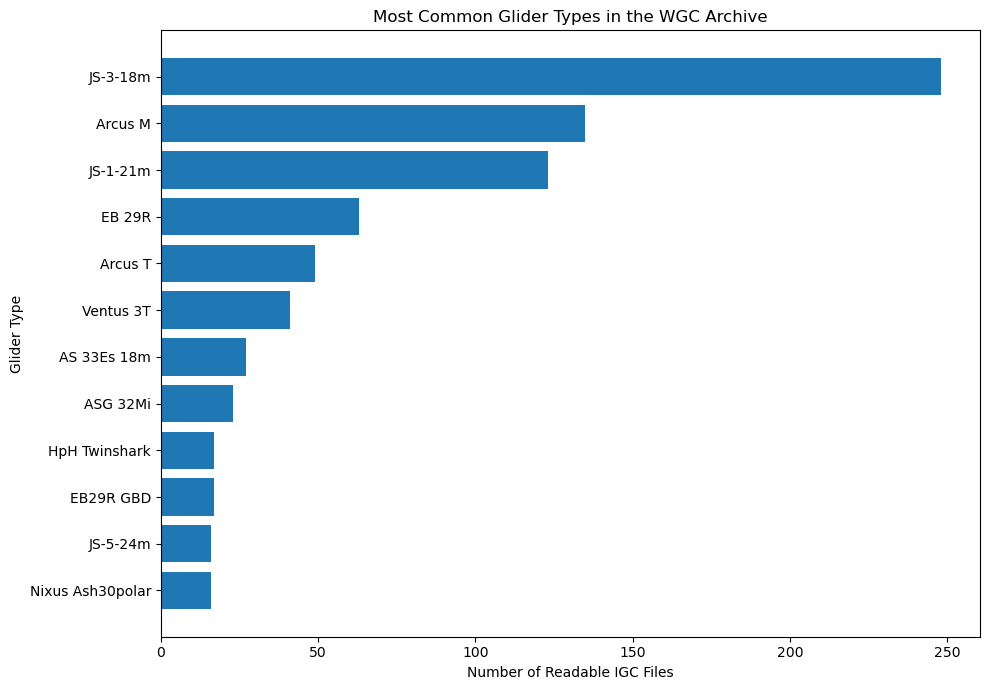

Saved figure to: ../reports/figures/wgc_top_aircraft_types.png


In [30]:
top_aircraft = aircraft_summary.head(12).sort_values(
    "File_Count",
    ascending=True,
)

aircraft_figure_path = (
    OUTPUT_FIGURE_DIR
    / "wgc_top_aircraft_types.png"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_aircraft["Glider_Type"],
    top_aircraft["File_Count"],
)

plt.title("Most Common Glider Types in the WGC Archive")
plt.xlabel("Number of Readable IGC Files")
plt.ylabel("Glider Type")
plt.tight_layout()

plt.savefig(
    aircraft_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Saved figure to: {aircraft_figure_path}")

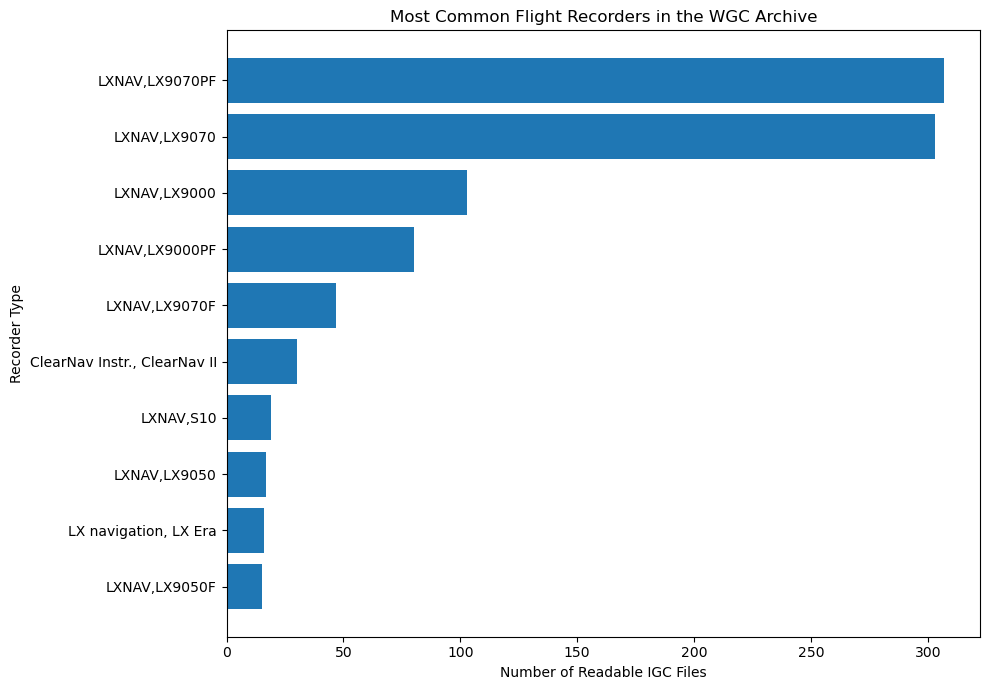

Saved figure to: ../reports/figures/wgc_top_recorder_types.png


In [31]:
top_recorders = recorder_summary.head(10).sort_values(
    "File_Count",
    ascending=True,
)

recorder_figure_path = (
    OUTPUT_FIGURE_DIR
    / "wgc_top_recorder_types.png"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_recorders["Recorder_Type"],
    top_recorders["File_Count"],
)

plt.title("Most Common Flight Recorders in the WGC Archive")
plt.xlabel("Number of Readable IGC Files")
plt.ylabel("Recorder Type")
plt.tight_layout()

plt.savefig(
    recorder_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Saved figure to: {recorder_figure_path}")

## 7. Recorded-Variable Availability 

The variables below were selected because they may provide evidence of motor activity, aircraft response, or data quality. Availability is based only on variables formally declared in each file's IGC I record.

In [32]:
sensor_columns = [
    "ENL",
    "GSP",
    "TAS",
    "ACZ",
    "VAT",
    "AOR",
    "AOP",
    "MOP",
    "RPM",
]

sensor_counts = (
    flight_inventory[sensor_columns]
    .sum()
    .sort_values(ascending=False)
)

sensor_availability = pd.DataFrame({
    "Variable": sensor_counts.index,
    "File_Count": sensor_counts.values,
})

sensor_availability["Percent_of_Readable_Files"] = (
    100
    * sensor_availability["File_Count"]
    / len(flight_inventory)
).round(1)

sensor_availability

,Variable,File_Count,Percent_of_Readable_Files
0,ENL,978,98.6
1,GSP,974,98.2
2,ACZ,922,92.9
3,VAT,920,92.7
4,TAS,907,91.4
5,AOR,687,69.3
6,AOP,687,69.3
7,MOP,465,46.9
8,RPM,62,6.2


In [33]:
availability_path = (
    OUTPUT_DATA_DIR
    / "wgc_variable_availability.csv"
)

sensor_availability.to_csv(
    availability_path,
    index=False,
)

print(f"Saved variable-availability table to: {availability_path}")

Saved variable-availability table to: ../data/processed/wgc_variable_availability.csv


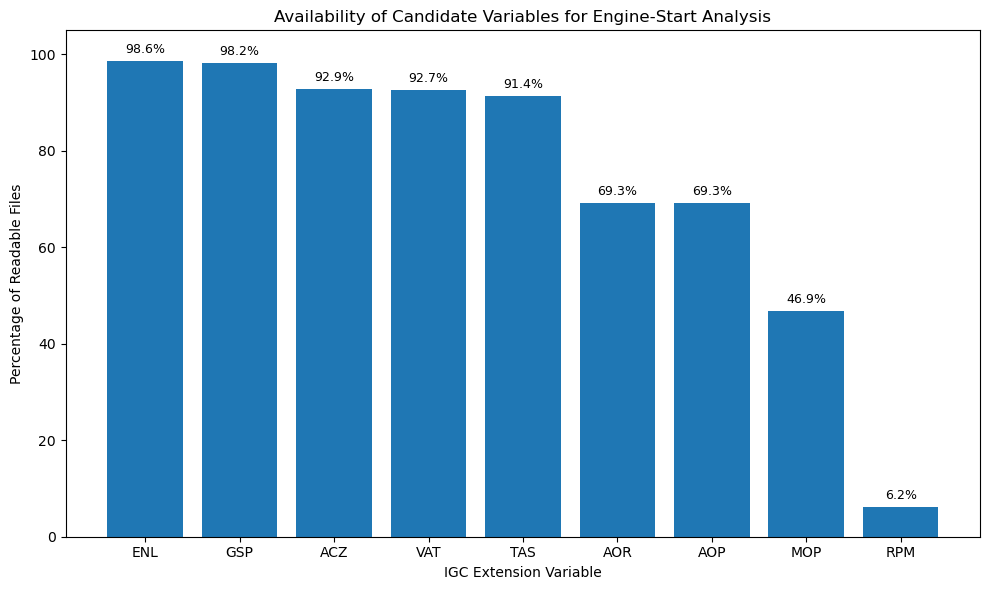

Saved figure to: ../reports/figures/wgc_candidate_variable_availability.png


In [34]:
figure_path = (
    OUTPUT_FIGURE_DIR
    / "wgc_candidate_variable_availability.png"
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    sensor_availability["Variable"],
    sensor_availability["Percent_of_Readable_Files"],
)

plt.title(
    "Availability of Candidate Variables "
    "for Engine-Start Analysis"
)
plt.xlabel("IGC Extension Variable")
plt.ylabel("Percentage of Readable Files")
plt.ylim(0, 105)

for bar, percentage in zip(
    bars,
    sensor_availability["Percent_of_Readable_Files"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Saved figure to: {figure_path}")

## 8. Availability of Candidate Variable Combinations 

A reliable engine-start evaluation is expected to benefit from combining motor-related measurements with the aircraft's subsequent flight response rather than relying on a single indicator. This section measures which candidate variables are declared together across the sponsor-provided IGC flight logs to determine which combinations are available for future engine-start analysis. These results describe data availability only and do not indicate that an engine event occurred or that any individual variable is more informative than another.

In [35]:
combination_definitions = {
    "ENL available": ["ENL"],
    "ENL + MOP": ["ENL", "MOP"],
    "ENL + RPM": ["ENL", "RPM"],
    "ENL + MOP + VAT": ["ENL", "MOP", "VAT"],
    "ENL + TAS + GSP": ["ENL", "TAS", "GSP"],
    "ENL + TAS + GSP + VAT": [
        "ENL",
        "TAS",
        "GSP",
        "VAT",
    ],
}

combination_rows = []

for name, required_variables in combination_definitions.items():
    mask = flight_inventory[required_variables].all(axis=1)
    count = int(mask.sum())

    combination_rows.append({
        "Variable_Combination": name,
        "File_Count": count,
        "Percent_of_Readable_Files": round(
            100 * count / len(flight_inventory),
            1,
        ),
    })

combination_summary = pd.DataFrame(combination_rows)

combination_summary

,Variable_Combination,File_Count,Percent_of_Readable_Files
0,ENL available,978,98.6
1,ENL + MOP,465,46.9
2,ENL + RPM,62,6.2
3,ENL + MOP + VAT,459,46.3
4,ENL + TAS + GSP,907,91.4
5,ENL + TAS + GSP + VAT,906,91.3


The results show that many flight logs contain multiple complementary variables, allowing future engine-start analysis to combine motor-related measurements with aircraft performance indicators when available. Because some variables are not recorded consistently across all aircraft and recorder systems, the final detection method should be designed to operate with different combinations of available evidence rather than requiring a single fixed sensor configuration.

In [36]:
combination_path = (
    OUTPUT_DATA_DIR
    / "wgc_variable_combinations.csv"
)

combination_summary.to_csv(
    combination_path,
    index=False,
)

print(f"Saved combination summary to: {combination_path}")

Saved combination summary to: ../data/processed/wgc_variable_combinations.csv


### Interpretation of variable Combinations 

The WGC archive provides broad support for an analysis that uses more than ENL alone. Most readable files also declare true airspeed, groundspeed, and variometer variables, allowing suspected motor events to be evaluated alongside the aircraft's subsequent speed and vertical response.

MOP is available in a substantial subset of files, while RPM is available in a smaller subset. The future workflow should therefore accommodate different combinations of available evidence rather than require one identical sensor package for every aircraft.

These results describe variable availability only. They do not establish that a motor event occurred, that a detected event was successful, or that any individual measurement should receive greater weight. Thresholds and evidence strength must be established by examining second-by-second values, manufacturer guidance, and sponsor-confirmed examples.

## 9. Data Quality and Current Limitations

The current audit identifies several limitations that must be considered before building an engine-start classifier:

- Variable availability differs across aircraft and recorder systems.
- An extension being declared does not guarantee that every recorded value is valid.
- ENL is an acoustic measurement and cannot independently prove successful engine operation.
- MOP and RPM are not available in every file.
- Pressure altitude and GNSS altitude require validation before calculating AGL.
- Terrain elevation data will be required to determine whether starts occurred above or below an AGL threshold.
- The archive's accompanying `Flt-times` CSV is empty.
- The exact mapping of files to sponsor-confirmed successful engine-start examples has not yet been documented in the analysis.
- This notebook measures data availability only and does not yet identify engine-start times or outcomes.

In [37]:
quality_summary = pd.DataFrame({
    "Measure": [
        "IGC files inventoried",
        "Files with an I record",
        "Files with at least one B record",
        "Files with valid B records",
        "Files containing invalid B records",
        "Files missing flight date",
        "Files missing glider type",
        "Files missing recorder type",
        "Files missing pressure-sensor metadata",
        "Files with parse errors",
    ],
    "Count": [
        len(flight_inventory),
        int(flight_inventory["has_i_record"].sum()),
        int((flight_inventory["b_record_count"] > 0).sum()),
        int((flight_inventory["valid_b_record_count"] > 0).sum()),
        int((flight_inventory["invalid_b_record_count"] > 0).sum()),
        int(flight_inventory["date"].isna().sum()),
        int(flight_inventory["glider_type"].isna().sum()),
        int(flight_inventory["recorder_type"].isna().sum()),
        int(flight_inventory["pressure_sensor"].isna().sum()),
        int(flight_inventory["parse_error"].notna().sum()),
    ],
})

quality_summary

,Measure,Count
0,IGC files inventoried,992
1,Files with an I record,978
2,Files with at least one B record,978
3,Files with valid B records,978
4,Files containing invalid B records,213
5,Files missing flight date,667
6,Files missing glider type,14
7,Files missing recorder type,14
8,Files missing pressure-sensor metadata,14
9,Files with parse errors,14


In [38]:
quality_path = OUTPUT_DATA_DIR / "wgc_quality_summary.csv"

quality_summary.to_csv(
    quality_path,
    index=False,
)

print(f"Saved quality summary to: {quality_path}")

Saved quality summary to: ../data/processed/wgc_quality_summary.csv


## 10. Preliminary Conclusions

The sponsor-provided WGC archive contains a large and technically rich collection of readable IGC flight logs representing multiple motorized sailplane models and recording systems. The files provide widespread access to ENL, speed, acceleration, and vertical-response variables, while MOP and RPM are available in smaller subsets.

The audit demonstrates that the future engine-start analysis does not need to rely exclusively on ENL. A multi-sensor approach can combine motor-related signals with altitude, speed, and vertical flight response. However, this notebook evaluates variable availability rather than engine-start outcomes. The next stage of the project is to parse the time-series flight records, identify the sponsor-confirmed successful examples, validate the applicable altitude threshold, and measure how relevant variables behave before and after known engine starts.

In [39]:
aircraft_summary.to_csv(
    OUTPUT_DATA_DIR / "wgc_aircraft_summary.csv",
    index=False
)

recorder_summary.to_csv(
    OUTPUT_DATA_DIR / "wgc_recorder_summary.csv",
    index=False
)

pressure_summary.to_csv(
    OUTPUT_DATA_DIR / "wgc_pressure_sensor_summary.csv",
    index=False
)